In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

torch.manual_seed(42)

In [20]:
num_samples = 1000
num_features = 4
num_classes = 3

X = torch.randn(num_samples, num_features)

true_W = torch.tensor([
    [1.0, -1.0, 0.5],
    [0.5, 1.5, -1.0],
    [-1.0, 0.5, 1.0],
    [1.0, 0.2, -0.5]
])

logits_for_label = X @ true_W
# logits_for_label.shape # torch.Size([1000, 3])

y = logits_for_label.argmax(dim=1)
# y.shape # torch.Size([1000])

In [21]:
dataset = TensorDataset(X, y)

train_size = int(len(dataset) * 0.70)
val_size = int(len(dataset) * 0.15)
test_size = len(dataset) - train_size - val_size
print(train_size, val_size, test_size) # 700 150 150

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset = dataset,
    lengths = [train_size, val_size, test_size],
    generator = generator
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print(f"batch_x shape: {batch_x.shape}")
print(f"batch_y shape: {batch_y.shape}")

700 150 150
batch_x shape: torch.Size([32, 4])
batch_y shape: torch.Size([32])


In [22]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=num_features, hidden_dim=32, num_classes=num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        logits = self.fc2(x)
        return logits

In [23]:
model = SimpleMLP(input_dim=4, hidden_dim=32, num_classes=3)
sample_X = torch.randn(5,4)
sample_logits = model(sample_X)

print(f"sample_logits shape: {sample_logits.shape}")

sample_logits shape: torch.Size([5, 3])


In [24]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = loss_fn(logits, batch_y)
        loss.backward()
        optimizer.step()

        batch_size = batch_x.size(0)
        correct = (logits.argmax(dim=1) == batch_y).sum().item()

        epoch_loss += loss.item() * batch_size
        epoch_correct += correct
        epoch_samples += batch_size

    avg_loss = epoch_loss / epoch_samples
    avg_acc = epoch_correct / epoch_samples

    return avg_loss, avg_acc

In [25]:
def evaluate(model, val_loader, loss_fn, device):
    model.eval()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)
        loss = loss_fn(logits, batch_y)

        batch_size = batch_x.size(0)
        correct = (logits.argmax(dim=1) == batch_y).sum().item()

        epoch_loss += loss.item() * batch_size
        epoch_correct += correct
        epoch_samples += batch_size

    avg_loss = epoch_loss / epoch_samples
    avg_acc = epoch_correct / epoch_samples

    return avg_loss, avg_acc

In [26]:
def fit(model, train_loader, val_loader, loss_fn, optimizer, device, epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }

        print(
            f"Epoch [{epoch:03d}/{epochs:03d}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} "
        )

    return history, best_state, best_epoch

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleMLP(input_dim=4, hidden_dim=32, num_classes=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

history, best_state, best_epoch = fit(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    loss_fn = loss_fn,
    optimizer = optimizer,
    device = device,
    epochs =20
)

Epoch [001/020] train_loss=0.7310 train_acc=0.7657 val_loss=0.4598 val_acc=0.9400 
Epoch [002/020] train_loss=0.3078 train_acc=0.9471 val_loss=0.1927 val_acc=0.9533 
Epoch [003/020] train_loss=0.1560 train_acc=0.9714 val_loss=0.1250 val_acc=0.9867 
Epoch [004/020] train_loss=0.1225 train_acc=0.9714 val_loss=0.0955 val_acc=0.9867 
Epoch [005/020] train_loss=0.1008 train_acc=0.9757 val_loss=0.0920 val_acc=0.9933 
Epoch [006/020] train_loss=0.0915 train_acc=0.9686 val_loss=0.0851 val_acc=0.9733 
Epoch [007/020] train_loss=0.0785 train_acc=0.9857 val_loss=0.0727 val_acc=0.9867 
Epoch [008/020] train_loss=0.0744 train_acc=0.9843 val_loss=0.0717 val_acc=0.9867 
Epoch [009/020] train_loss=0.0717 train_acc=0.9843 val_loss=0.0671 val_acc=0.9867 
Epoch [010/020] train_loss=0.0631 train_acc=0.9857 val_loss=0.0641 val_acc=0.9800 
Epoch [011/020] train_loss=0.0579 train_acc=0.9914 val_loss=0.0602 val_acc=0.9800 
Epoch [012/020] train_loss=0.0566 train_acc=0.9857 val_loss=0.0642 val_acc=0.9733 
Epoc

In [30]:
print(f"best validation epoch: {best_epoch}")

model.load_state_dict(best_state)

best validation epoch: 18


<All keys matched successfully>

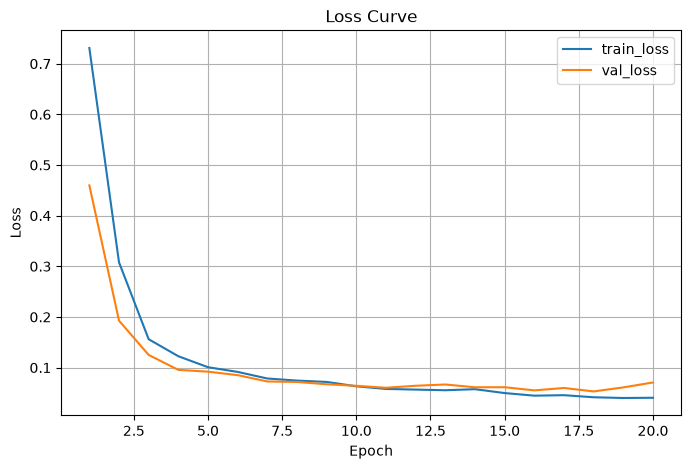

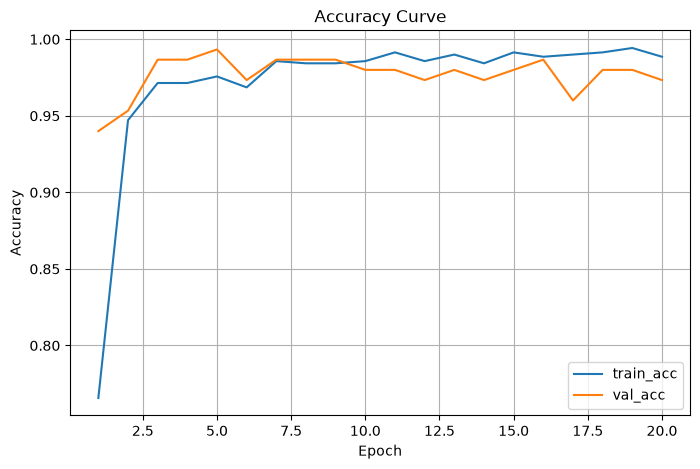

In [31]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)

In [32]:
test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
print(f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

test_loss=0.0204, test_acc=1.0000
